 # Smart Study Time Recommender 💡

# 1.import Libraries

In [5]:
import pandas as pd
import numpy as np

 # 2.Load dataset

In [3]:
df=pd.read_csv("student_habits.csv")

# 3.Data Understanding

In [4]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [7]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


# 4. Creating Target Variable

In [8]:
def smart_study_time(row):
    
    # High performers (GPA high + good sleep)
    if row['GPA'] >= 3.2 and row['Sleep_Hours_Per_Day'] >= 7:
        return "Morning"
    
    # High stress + less sleep → night study risky
    elif row['Stress_Level'] == "High":
        return "Afternoon"
    
    # High social + distraction → late night better
    elif row['Social_Hours_Per_Day'] >= 3:
        return "Night"
    
    # Balanced case
    else:
        return "Afternoon"

df['Best_Study_Time'] = df.apply(smart_study_time, axis=1)

df[['GPA', 'Sleep_Hours_Per_Day', 'Stress_Level', 'Best_Study_Time']].head()
    

,GPA,Sleep_Hours_Per_Day,Stress_Level,Best_Study_Time
0,2.99,8.7,Moderate,Afternoon
1,2.75,8.0,Low,Night
2,2.67,9.2,Low,Afternoon
3,2.88,7.2,Moderate,Afternoon
4,3.51,6.5,High,Afternoon


# 5.Feature Selection

In [16]:
X = df[[
    'Study_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day',
    'GPA'
]].copy()

# 6.Data Encoding 

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Stress_Level_Encoded'] = le.fit_transform(df['Stress_Level'])

X['Stress_Level'] = df['Stress_Level_Encoded']

# 7.Defining Traget Variable

In [11]:
y = df['Best_Study_Time']

# 8.Splitting Dataset

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)


# 9.Model Training

In [29]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=30,
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, n_estimators=30, random_state=42)

# 10. Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9966666666666667


# 11.Prediction

In [31]:
sample = pd.DataFrame([[6, 7.5, 2, 3, 3.2, 1]],columns=X.columns)  
# Study, Sleep, Social, Physical, GPA, Stress

prediction = model.predict(sample)

print("Recommended Study Time:", prediction[0])

Recommended Study Time: Morning


# 12.Analysis

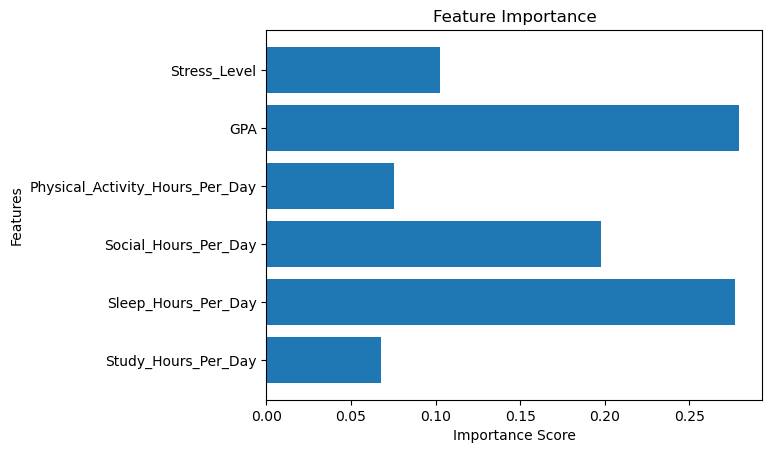

In [32]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

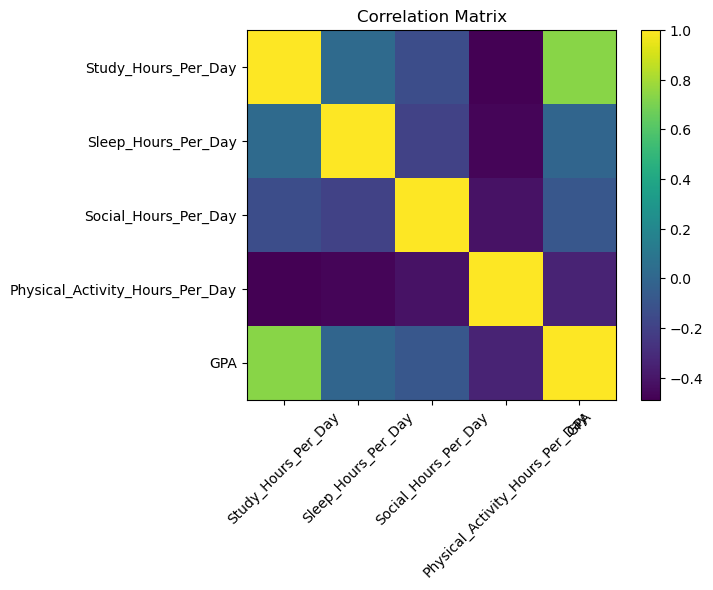

In [33]:

corr = df[['Study_Hours_Per_Day','Sleep_Hours_Per_Day',
           'Social_Hours_Per_Day','Physical_Activity_Hours_Per_Day',
           'GPA']].corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()